In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

# Select parent sources who have at least one significant emission line (>5 S/N ratio)

In [3]:
FIT = FitSpectrum()
DP = DP()

# dp_parent, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/all_catalog.fits')
# ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dp_parent['TARGETID'].to_list())
# # ALL_SPECTRA = ALL_SPECTRA.subtype_filter(subtype='QSO', exclude=True)
# ALL_SPECTRA = ALL_SPECTRA.stack_data()
# ALL_SPECTRA = ALL_SPECTRA.shift_to_rest_frame()
# print('Total number of spectra:', len(ALL_SPECTRA.targetID))

In [4]:
# ALL_SPECTRA = FIT.label_emission_lines(ALL_SPECTRA, 5)
# # ALL_SPECTRA = FIT.significant_emission_filter(ALL_SPECTRA)
# print('Total number of spectra:', len(ALL_SPECTRA.targetID))

In [5]:
# ALL_SPECTRA = ALL_SPECTRA.shrink_dataset(5)
# print('Number of spectra after shrinking:', len(ALL_SPECTRA.targetID))

In [6]:
# dp_parent, model_1comp, left_2comp, right_2comp = DP.fit_all(data_class=ALL_SPECTRA, n_jobs=10)
# DP.get_catalog(df=dp_parent, fname='./catalogs/all_catalog_test.fits', model_1comp=model_1comp, left_2comp=left_2comp, right_2comp=right_2comp)



In [7]:
dp_parent, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/all_catalog_test.fits')
dp_sample, model_1comp, left_2comp, right_2comp = DP.select_dp_sample(dp_parent, model_1comp, left_2comp, right_2comp)
DP.get_catalog(df=dp_sample, fname='./catalogs/dp_catalog_test.fits', model_1comp=model_1comp, left_2comp=left_2comp, right_2comp=right_2comp)


In [8]:
dp_sample, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/dp_catalog_test.fits')
dp_sample.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank,dp_count
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.451893,-78.319199,50.218773,30.572901,...,2,5,8,3,6,0,1,7,9,2
1,39627739380057506,177.058472,-1.984356,0.102379,10.324259,-0.880754,112.483803,-62.245144,42.930370,68.479820,...,5,3,9,8,2,0,1,4,6,1
2,39627739380058467,177.097977,-1.888290,0.123931,10.402426,1.031611,88.860611,-27.739218,29.598230,52.082478,...,3,6,9,8,7,0,1,2,4,3
3,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,80.845169,-86.188843,52.286289,59.410812,...,6,3,9,8,4,0,1,2,5,2
4,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,88.226196,-73.512642,38.063850,50.911797,...,3,2,9,8,7,0,1,4,6,5


In [9]:
print(len(dp_sample))

18277


In [10]:
dp_cols = ['OII3726_dp', 'OII3729_dp',
            'Hbeta_dp',
            'OIII4959_dp', 'OIII5007_dp',
            'NII6548_dp', 'Halpha_dp', 'NII6583_dp', 
            'SII6716_dp', 'SII6731_dp']
dp_sample[['TARGETID']+dp_cols+['dp_count']].head(10)

,TARGETID,OII3726_dp,OII3729_dp,Hbeta_dp,OIII4959_dp,OIII5007_dp,NII6548_dp,Halpha_dp,NII6583_dp,SII6716_dp,SII6731_dp,dp_count
0,39627739380056564,False,False,False,False,False,False,True,True,False,False,2
1,39627739380057506,False,False,False,False,False,False,True,False,False,False,1
2,39627739380058467,False,False,False,False,False,False,True,True,True,False,3
3,39627739380060210,False,False,False,False,False,False,True,True,False,False,2
4,39627739380061198,False,True,True,False,False,True,True,True,True,True,5
5,39627739384252917,False,False,False,False,False,False,True,True,False,False,2
6,39627739384253866,False,False,False,False,False,False,True,True,False,False,2
7,39627739384254171,False,False,False,False,False,False,True,False,False,False,1
8,39627739384254755,False,False,False,False,False,False,True,True,True,True,3
9,39627739388446113,True,True,True,False,False,True,True,True,True,True,3


OII3726: 1150
OII3729: 2001
Hbeta: 3891
OIII4959: 208
OIII5007: 1252
NII6548: 1652
Halpha: 18122
NII6583: 12180
SII6716: 4538
SII6731: 2425


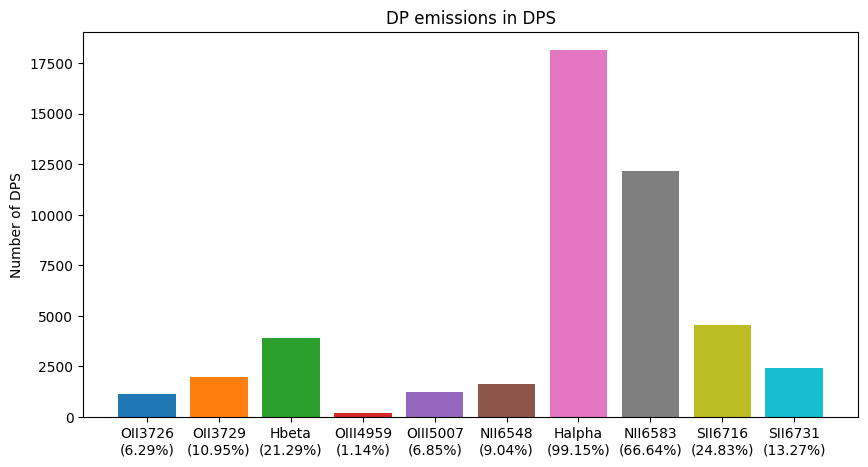

In [15]:

plt.figure(figsize=(10, 5))
for col in dp_cols:
    dp_sample[col] = dp_sample[col].fillna(False)
    print(f"{col[:-3]}: {np.sum(dp_sample[col])}")
    plt.bar(col[:-3]+f'\n({np.sum(dp_sample[col]) / len(dp_sample):.2%})', np.sum(dp_sample[col]))
# plt.xlabel("Emission Line")
plt.ylabel("Number of DPS")
plt.title("DP emissions in DPS")
# plt.savefig("./figures/Jan2/dp_candidates_emission.png")
plt.show()

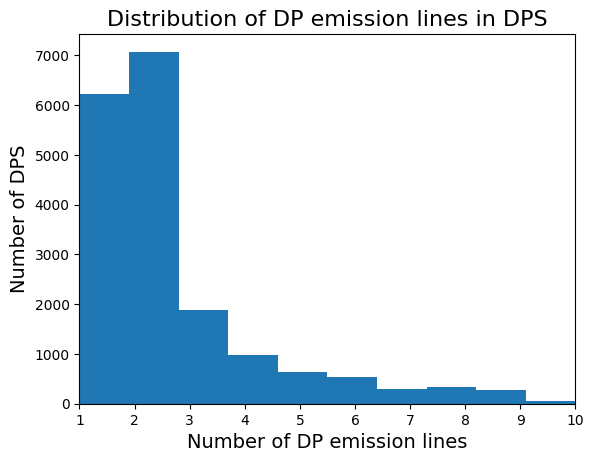

In [24]:
plt.hist(dp_sample['dp_count'])
# plt.yscale('log')
plt.xlim(left=1, right=10)
plt.xlabel("Number of DP emission lines", fontsize=14)
plt.ylabel("Number of DPS", fontsize=14)
plt.title("Distribution of DP emission lines in DPS", fontsize=16)
plt.savefig('./figures/Jan22/dp_count.png')
plt.show()